In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('./data/athlete_events.csv')
region_df = pd.read_csv('./data/noc_regions.csv')

In [ ]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN


In [ ]:
df.shape

(271116, 15)

In [ ]:
region_df.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [ ]:
df = df.merge(region_df, how="left",left_on="NOC",right_on="NOC")

In [ ]:
df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [ ]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(1385)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Medal'].value_counts()

Medal
Gold      13369
Bronze    13295
Silver    13108
Name: count, dtype: int64

In [ ]:
df.shape

(269731, 17)

In [ ]:
pd.get_dummies(df['Medal']).astype(int)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,0
4,0,0,0
...,...,...,...
271111,0,0,0
271112,0,0,0
271113,0,0,0
271114,0,0,0


In [ ]:
# concat these two horizontally to get the final dataframe
final_df = pd.concat([df,pd.get_dummies(df['Medal']).astype(int)],axis=1)

In [ ]:
final_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN,0,0,0
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN,0,0,0
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN,0,0,0
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN,0,0,0


In [ ]:
from matplotlib import pyplot as plt

In [ ]:
year_wise_country_count = (
    final_df
        .groupby('Year')['region']
        .nunique()
        .reset_index(name='Country_Count')
        .sort_values('Year')
)

In [ ]:
# no of countrues pRTICIPATED IN THE
year_wise_country_count.head()

,Year,Country_Count
0,1896,12
1,1900,31
2,1904,14
3,1906,20
4,1908,22


In [ ]:
import plotly.express as plot

In [ ]:
year_wise_country_count.head()

,Year,Country_Count
0,1896,12
1,1900,31
2,1904,14
3,1906,20
4,1908,22


In [ ]:
final_df.groupby("NOC").sum()[["Gold","Silver","Bronze"]].reset_index().sort_values(by=["Gold","Silver","Bronze"], ascending=False)

,NOC,Gold,Silver,Bronze
216,USA,2638,1641,1358
214,URS,1082,732,689
79,GER,745,674,746
74,GBR,677,739,651
100,ITA,575,531,531
...,...,...,...,...
221,VIN,0,0,0
222,VNM,0,0,0
224,YAR,0,0,0
225,YEM,0,0,0


In [ ]:
final_df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN,0,0,0
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN,0,0,0
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN,0,0,0
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN,0,0,0


In [ ]:
final_df[(final_df["Year"] == 1924) ]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
39,15,Arvo Ossian Aaltonen,M,34.0,NaN,NaN,Finland,FIN,1924 Summer,1924,Summer,Paris,Swimming,Swimming Men's 200 metres Breaststroke,NaN,Finland,NaN,0,0,0
132,47,Erling Rudolf Aastad,M,26.0,177.0,74.0,Norway,NOR,1924 Summer,1924,Summer,Paris,Athletics,Athletics Men's Long Jump,NaN,Norway,NaN,0,0,0
152,58,Georgi Abadzhiev,M,NaN,NaN,NaN,Bulgaria,BUL,1924 Summer,1924,Summer,Paris,Cycling,"Cycling Men's Road Race, Individual",NaN,Bulgaria,NaN,0,0,0
153,58,Georgi Abadzhiev,M,NaN,NaN,NaN,Bulgaria,BUL,1924 Summer,1924,Summer,Paris,Cycling,"Cycling Men's Road Race, Team",NaN,Bulgaria,NaN,0,0,0
181,79,Carlos Abarca Gonzlez,M,23.0,NaN,NaN,Chile,CHI,1924 Summer,1924,Summer,Paris,Boxing,Boxing Men's Featherweight,NaN,Chile,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270673,135364,Vittorio Zucca,M,28.0,NaN,NaN,Italy,ITA,1924 Summer,1924,Summer,Paris,Athletics,Athletics Men's 100 metres,NaN,Italy,NaN,0,0,0
270676,135366,Francesco Zucchetti,M,22.0,NaN,NaN,Italy,ITA,1924 Summer,1924,Summer,Paris,Cycling,"Cycling Men's Team Pursuit, 4,000 metres",Gold,Italy,NaN,0,1,0
270794,135427,Frank Thomas Zuna,M,31.0,175.0,69.0,United States,USA,1924 Summer,1924,Summer,Paris,Athletics,Athletics Men's Marathon,NaN,USA,NaN,0,0,0
271010,135521,Anton Zwerina,M,23.0,NaN,66.0,Austria,AUT,1924 Summer,1924,Summer,Paris,Weightlifting,Weightlifting Men's Lightweight,Silver,Austria,NaN,0,0,1


In [ ]:
medal_tally = final_df.drop_duplicates(subset=["NOC","Year","Games","Medal","Season","City","Event","Sport"])

In [ ]:
medal_tally = medal_tally.groupby("NOC").sum()[["Gold","Silver","Bronze"]].sort_values(by=["Gold","Silver","Bronze"],ascending=False).reset_index()

In [ ]:
result = (
    final_df
    .drop_duplicates(subset=["region", "Event", "Games", "Medal", "City", "Year", "NOC"])
    .dropna(subset=["Medal"])                                    # ✅ list, not string
    .pipe(lambda df: df[
        (df["region"] == "USA")        # ✅ & with parentheses, scoped to chain
    ])
                                                       # ✅ total row count
)

result = result.pivot_table(index="Sport",columns="Year",values="Medal",aggfunc="count").fillna(0)

In [ ]:

import plotly.figure_factory as ff

In [ ]:
age_data = final_df.drop_duplicates(subset=["Name","region"])["Age"].dropna()
gold_age_wise = final_df[final_df["Medal"] == "Gold"]["Age"].dropna()
silver_age_wise = final_df[final_df["Medal"] == "Silver"]["Age"].dropna()
bronze_age_wise = final_df[final_df["Medal"] == "Bronze"]["Age"].dropna()
weight_data = final_df[final_df["Weight"] > 70 ]["Age"].dropna()
fig2 = ff.create_distplot(
[age_data,gold_age_wise,silver_age_wise,bronze_age_wise,weight_data],                  # ✅ list of arrays
['Age Distribution','Gold Analysis','Silver Analysis','Bronze Analysis','Weight Analysis'],
show_hist=False,
show_rug=False
)
fig2.show()

<Axes: xlabel='Year', ylabel='Sport'>

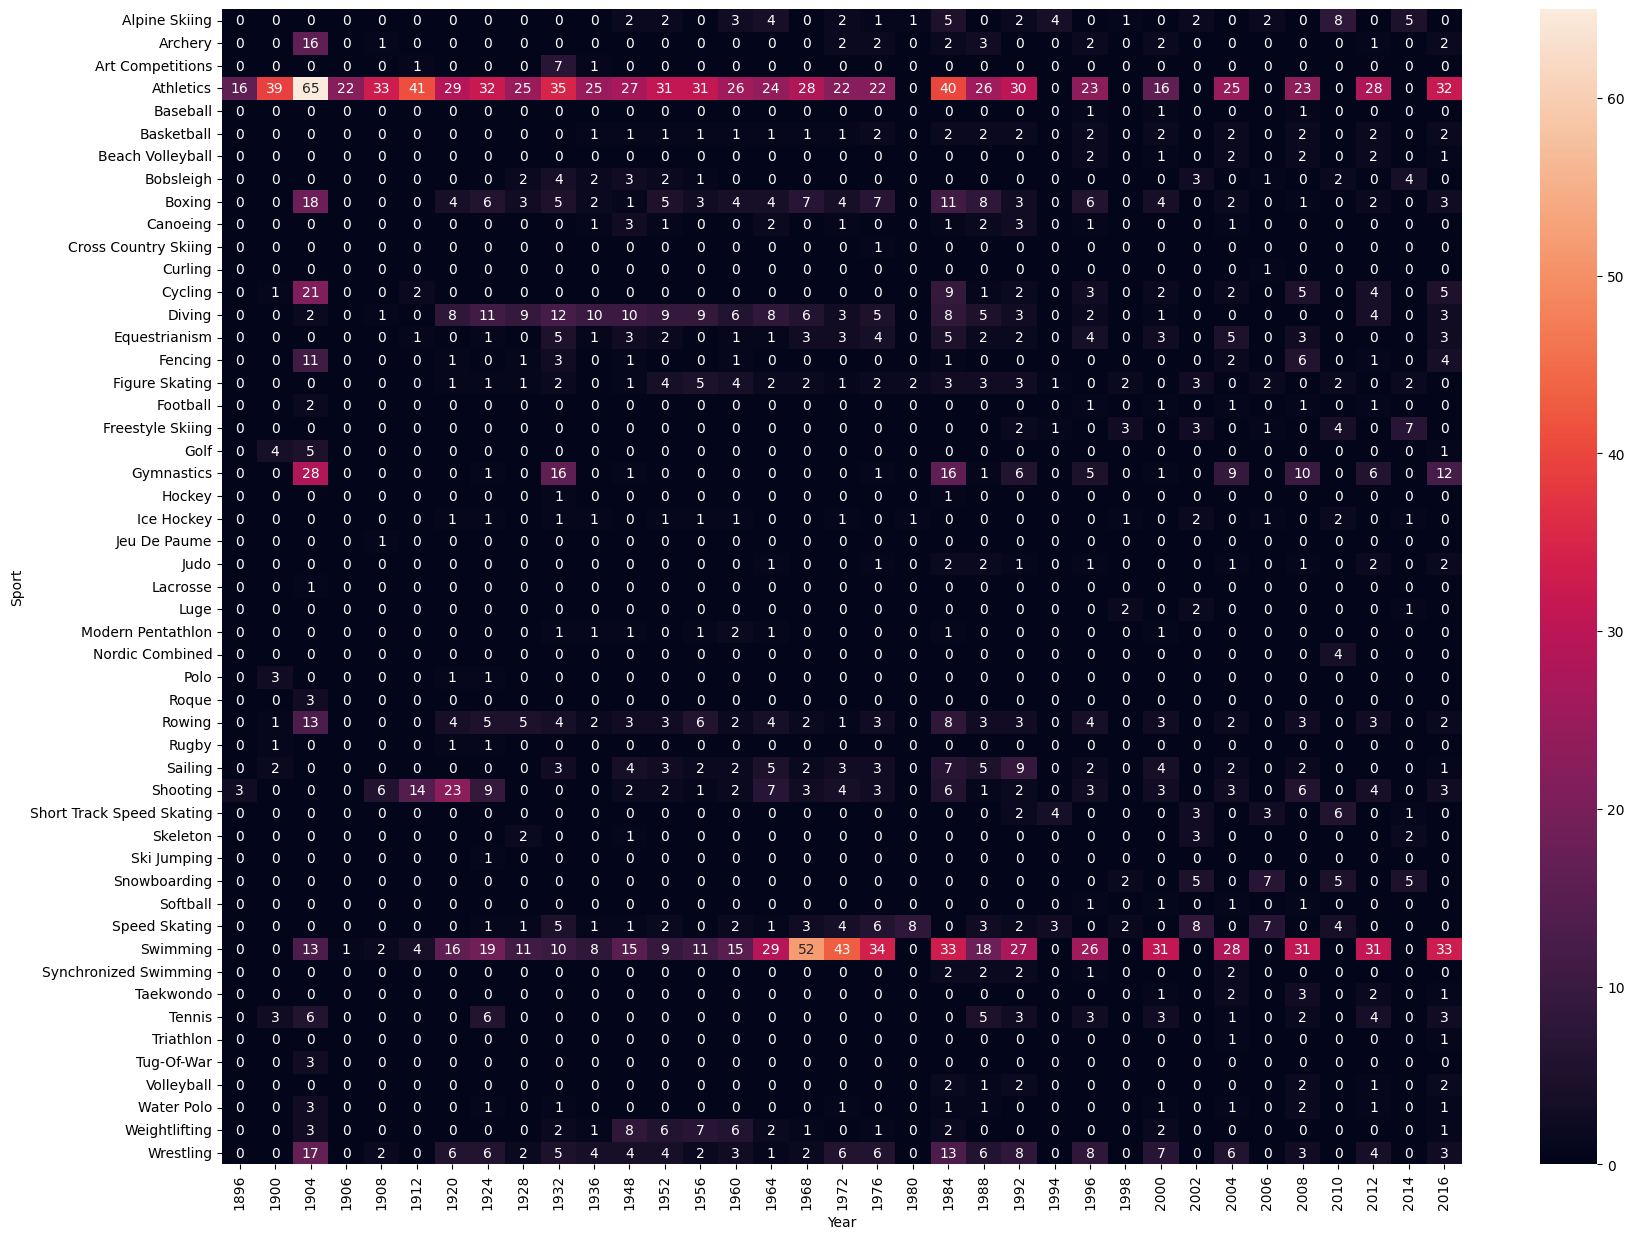

In [ ]:


fig, ax = plt.subplots(figsize=(20, 15))     # ✅ control width x height


sns.heatmap(result,annot=True)


In [ ]:
    # Gold per sport with age distribution
famous_sport = final_df["Sport"].tolist()
famous_sport

In [ ]:
medal_tally[medal_tally["NOC"] == "IND"]

,NOC,Gold,Silver,Bronze
51,IND,10,7,12


In [ ]:
final_df["Total"] = final_df["Gold"] + final_df["Silver"] + final_df["Bronze"]

In [ ]:
# Step 1: Rank all countries by total medals
new_df = (
    final_df.groupby('Name')[["Total"]]
    .sum()
    .sort_values(by="Total", ascending=False)
    .reset_index()
)

# Step 2: Merge, then break down by Sport — keep both Gold and Total
result = (
    final_df.merge(new_df["Name"], on="Name")          # bring in top context
    .groupby(["Name", "Sport","NOC"])[["Total"]]     # ✅ keep Total so sort works
    .sum()
    .sort_values(by="Total", ascending=False)           # ✅ now valid
    .reset_index()
)

print(result[result["Sport"] == "Hockey"].head(10))

                             Name   Sport  NOC  Total
544             Udham Singh Kular  Hockey  IND      4
736        Leslie Walter Claudius  Hockey  IND      4
770   Luciana Paula "Lucha" Aymar  Hockey  ARG      4
784        Teun Floris de Nooijer  Hockey  NED      4
971                Salim Sherwani  Hockey  PAK      3
973                   Saeed Anwar  Hockey  PAK      3
1039           Christopher Zeller  Hockey  GER      3
1054       Damon Laurance Diletti  Hockey  AUS      3
1093            Ellen Marijn Hoog  Hockey  NED      3
1150              Jay Jason Stacy  Hockey  AUS      3


In [ ]:
final_df["Total"] = final_df["Gold"] + final_df["Silver"] + final_df["Bronze"]
newdf = final_df.groupby(["region","Year"])[["Total"]].sum().sort_values(by=['Year','Total'],ascending=[True,False]).reset_index()

In [ ]:
newdf


,region,Year,Total
0,Greece,1896,48
1,Germany,1896,32
2,USA,1896,20
3,France,1896,11
4,UK,1896,9
...,...,...,...
3253,"Virgin Islands, British",2016,0
3254,"Virgin Islands, US",2016,0
3255,Yemen,2016,0
3256,Zambia,2016,0


In [ ]:
def top_10_data(final_df,sport):
    # add total column
    final_df["Total"] = final_df["Gold"] + final_df["Silver"] + final_df["Bronze"]
    # Step 1: Rank all countries by total medals
    new_df = (
        final_df.groupby('Name')[["Total"]]
        .sum()
        .sort_values(by="Total", ascending=False)
        .reset_index()
    )

    # Step 2: Merge, then break down by Sport — keep both Gold and Total
    result = (
        final_df.merge(new_df["Name"], on="Name")          # bring in top context
        .groupby(["Name", "Sport","NOC"])[["Total"]]     # ✅ keep Total so sort works
        .sum()
        .sort_values(by="Total", ascending=False)           # ✅ now valid
        .reset_index()
    )
    if(sport == "Overall"):
        return result.head(10)
    else:
        return result[result["Sport"] == "Swimming"].head(10)



In [ ]:
top_10_data(final_df,"Swimming")

,Name,Sport,NOC,Total
0,"Michael Fred Phelps, II",Swimming,USA,28
8,Ryan Steven Lochte,Swimming,USA,12
9,"Dara Grace Torres (-Hoffman, -Minas)",Swimming,USA,12
11,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",Swimming,USA,12
13,Natalie Anne Coughlin (-Hall),Swimming,USA,12
16,Mark Andrew Spitz,Swimming,USA,11
18,"Matthew Nicholas ""Matt"" Biondi",Swimming,USA,11
22,Franziska van Almsick,Swimming,GER,10
27,"Gary Wayne Hall, Jr.",Swimming,USA,10
45,Shirley Frances Babashoff,Swimming,USA,9


In [ ]:
new_df

,Name,Total
0,"Michael Fred Phelps, II",28
1,Larysa Semenivna Latynina (Diriy-),18
2,Nikolay Yefimovich Andrianov,15
3,Edoardo Mangiarotti,13
4,Takashi Ono,13
...,...,...
134727,A. Hurtado Vargas,0
134728,A. Hussain Ahmed,0
134729,A. J. J. Fridt,0
134730,"A. J. Tyronne Benildus ""Benny"" Fernando",0


In [ ]:
# Step 1: Get top 5 countries by Total medals
top5_df = (
    final_df.groupby('Name')[["Gold", "Silver", "Bronze", "Total"]]
    .sum()
    .sort_values(by="Total", ascending=False)
    .head(5)
    .reset_index()  # brings 'Name' back as a column
)

# Step 2: Filter original df to only rows where Name is in top 5
top5_names = top5_df["Name"].tolist()

result = (
    final_df[final_df["Name"].isin(top5_names)]
    .groupby(["Name", "Sport"])[["Gold", "Silver", "Bronze", "Total"]]
    .sum()
    .sort_values(by=["Name", "Total"], ascending=[True, False])
    .reset_index()
)

print(result)

                                 Name       Sport  Gold  Silver  Bronze  Total
0                 Edoardo Mangiarotti     Fencing     6       5       2     13
1  Larysa Semenivna Latynina (Diriy-)  Gymnastics     9       5       4     18
2             Michael Fred Phelps, II    Swimming    23       3       2     28
3        Nikolay Yefimovich Andrianov  Gymnastics     7       5       3     15
4                         Takashi Ono  Gymnastics     5       4       4     13
5                         Takashi Ono        Judo     0       0       0      0
